# Cancer Type Classification from RNA-Seq (Preprocessing)

## Data Pre-processing (Leakage-safe)
This notebook section prepares RNA-Seq gene expression data for downstream analysis and modeling.

**Key requirements addressed:**
- Correct loading & alignment of features and labels
- Robust quality checks (duplicates, missing values)
- Proper label encoding (preserve mapping)
- Train/test split *before* scaling/selection to avoid leakage
- Leakage-safe preprocessing pipeline:
  - Imputation
  - Optional log transform (for count-like data)
  - Remove constant genes (variance threshold)
  - Standard scaling
- Keep feature (gene) names after filtering for interpretability later (xAI)

**Output:**
- `X_train_proc`, `X_test_proc`, `y_train`, `y_test`
- `kept_genes.csv`, `label_classes.csv`


In [17]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

RANDOM_STATE = 42

DATA_DIR = Path("../data")

## Step 1 — Load the data

We load:
- `data.csv`: gene expression matrix (samples × genes)
- `labels.csv`: cancer type label for each sample

We immediately print shapes and a preview to detect formatting issues early.

In [21]:
X = pd.read_csv(DATA_DIR / "data.csv")
y = pd.read_csv(DATA_DIR / "labels.csv")

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head(3))
display(y.head(3))

X shape: (801, 20532)
y shape: (801, 2)


,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0


,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD


## Step 2 — Basic consistency checks

We verify:
- The number of samples in features and labels match
- Duplicate samples in the feature table are removed (exact duplicates)

In [46]:
# sample count check
assert len(X) == len(y), "Number of rows in data.csv and labels.csv must match."

# remove exact duplicate feature rows (if any)
dup_count = int(X.duplicated().sum())
if dup_count > 0:
    keep_mask = ~X.duplicated()
    X = X.loc[keep_mask].reset_index(drop=True)
    y = y.loc[keep_mask].reset_index(drop=True)

print("Duplicate feature rows removed:", dup_count)
print("X shape after duplicates handling:", X.shape)

Duplicate feature rows removed: 0
X shape after duplicates handling: (801, 20532)


## Step 3 — Prepare labels (2nd column) and encode

We:
- Select cancer type from the **second column** of `labels.csv`
- Clean whitespace
- Encode labels into integers using `LabelEncoder`
- Store the class mapping for interpretation later

In [51]:
# cancer labels are stored in the second column (index 1)
y_raw = y.iloc[:, 1].astype(str).str.strip()

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

print("Classes:", list(le.classes_))
print("Class counts:\n", pd.Series(y_raw).value_counts())

Classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']
Class counts:
 Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


## Step 4 — Ensure feature matrix is numeric

RNA-Seq ML models require numeric input.
Here we:
- Identify any non-numeric columns
- Remove columns that behave like identifiers (non-numeric content)
- Convert the remaining feature columns to numeric (coercing unexpected entries to NaN)

Missing values (if any) will be handled later via imputation in the pipeline.

In [54]:
# Identify non-numeric columns
non_numeric_cols = X.columns[X.dtypes == "object"].tolist()

# Drop ID-like non-numeric columns (mostly non-numeric after coercion)
id_like_cols = []
for col in non_numeric_cols:
    converted = pd.to_numeric(X[col], errors="coerce")
    if converted.isna().mean() > 0.5:
        id_like_cols.append(col)

if len(id_like_cols) > 0:
    X = X.drop(columns=id_like_cols)

# Convert remaining columns to numeric
X = X.apply(pd.to_numeric, errors="coerce")

print("Final X shape (numeric features):", X.shape)
print("Any object dtype left?", (X.dtypes == "object").any())
print("Total missing values in X:", int(X.isna().sum().sum()))

Final X shape (numeric features): (801, 20531)
Any object dtype left? False
Total missing values in X: 0


## Step 5 — Train/test split (stratified)

We split the dataset before fitting any preprocessing steps to ensure a leakage-safe workflow.
Stratification keeps class proportions similar in train and test sets.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (640, 20531) Test shape: (161, 20531)


## Step 6 — Decide on log transformation (optional)

Depending on whether the expression values are raw counts or already normalized,
a log1p transform may be useful.

We compute a quick diagnostic on the training set:
- maximum value
- whether values look integer-like

You can set `use_log=True` if the data appears count-like and non-negative.

In [62]:
X_train_np = X_train.to_numpy(dtype=float)

max_val = float(np.nanmax(X_train_np))
integer_like = bool(np.allclose(X_train_np, np.round(X_train_np), atol=1e-6, equal_nan=True))

print("Max value (train):", max_val)
print("Looks integer-like:", integer_like)

use_log = False  # set True if appropriate for your dataset
print("use_log =", use_log)

Max value (train): 20.7788287118
Looks integer-like: False
use_log = False


## Step 7 — Build preprocessing pipeline (fit on train only)

Pipeline steps:
1) Impute missing values (median)
2) Optional log1p transform
3) Remove constant genes/features (variance = 0)
4) Standardize features (mean=0, std=1)

This produces a numeric, scaled dataset suitable for PCA, SVM, logistic regression, etc.


In [65]:
class OptionalLog1p(BaseEstimator, TransformerMixin):
    def __init__(self, enabled=False):
        self.enabled = enabled

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not self.enabled:
            return X
        X = np.asarray(X)
        if np.nanmin(X) < 0:
            raise ValueError("Log transform requires non-negative values.")
        return np.log1p(X)

preprocess = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("log1p", OptionalLog1p(enabled=use_log)),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("scale", StandardScaler(with_mean=True, with_std=True)),
])

## Step 8 — Fit preprocessing on training set and transform train/test

We fit the preprocessing pipeline on training data only and then apply it to both splits.

In [68]:
X_train_proc = preprocess.fit_transform(X_train, y_train)
X_test_proc = preprocess.transform(X_test)

print("Processed train shape:", X_train_proc.shape)
print("Processed test shape:", X_test_proc.shape)

Processed train shape: (640, 20254)
Processed test shape: (161, 20254)


## Step 9 — Store remaining feature names after filtering

After removing constant features, some genes may be dropped.
We store the retained feature names for later interpretability and xAI analysis.

In [73]:
vt = preprocess.named_steps["variance_filter"]
kept_mask = vt.get_support()
kept_genes = X_train.columns[kept_mask].to_list()

print("Number of retained genes/features:", len(kept_genes))
print("First 10 retained genes:", kept_genes[:10])

Number of retained genes/features: 20254
First 10 retained genes: ['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_6', 'gene_7', 'gene_8', 'gene_9', 'gene_10']


## Step 10 — Save outputs for reproducibility

We save processed arrays and metadata so modeling and analysis can be performed
without repeating preprocessing.

In [76]:
np.save("X_train_proc.npy", X_train_proc)
np.save("X_test_proc.npy", X_test_proc)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

pd.Series(kept_genes, name="gene").to_csv("kept_genes.csv", index=False)
pd.Series(le.classes_, name="class_name").to_csv("label_classes.csv", index=False)

print("Saved preprocessing outputs successfully.")

Saved preprocessing outputs successfully.


# Exploratory Data Analysis (EDA) and PCA

In this section, we explore the structure of the RNA-Seq dataset after preprocessing.

## Objectives
- Examine class distribution
- Understand global structure of gene expression data
- Visualize samples in low-dimensional space using PCA
- Assess whether cancer types show separable patterns

All analyses are performed on the **training set** to maintain a leakage-safe workflow.

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

## Step 1 — Load preprocessed data

We load the outputs generated during preprocessing.
These include:
- scaled and filtered training features
- training labels
- label class names

In [90]:
X_train_proc = np.load("processed/X_train_proc.npy")
y_train = np.load("processed/y_train.npy")

label_classes = pd.read_csv("processed/label_classes.csv")["class_name"].tolist()

print("X_train_proc shape:", X_train_proc.shape)
print("y_train shape:", y_train.shape)
print("Classes:", label_classes)

X_train_proc shape: (640, 20254)
y_train shape: (640,)
Classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']


## Class Distribution in Training and Test Sets

To verify that stratified splitting preserved class proportions,
we visualize the class distribution in both the training and test sets.metrics


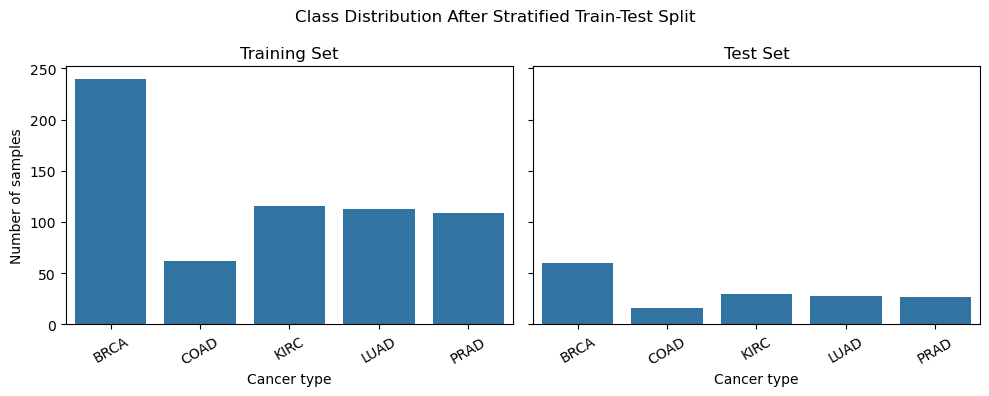

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count classes
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

train_labels = [label_classes[i] for i in train_counts.index]
test_labels = [label_classes[i] for i in test_counts.index]

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.barplot(
    x=train_labels,
    y=train_counts.values,
    ax=axes[0]
)
axes[0].set_title("Training Set")
axes[0].set_xlabel("Cancer type")
axes[0].set_ylabel("Number of samples")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    x=test_labels,
    y=test_counts.values,
    ax=axes[1]
)
axes[1].set_title("Test Set")
axes[1].set_xlabel("Cancer type")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Class Distribution After Stratified Train-Test Split")
plt.tight_layout()
plt.show()

**Inference:**  
The class distributions in the training and test sets are highly similar,
confirming that stratified sampling preserved class proportions and supports
fair model evaluation.

## Step 3 — Principal Component Analysis (PCA)

RNA-Seq data is extremely high-dimensional (thousands of genes).
PCA helps by:
- reducing dimensionality
- capturing dominant sources of variance
- enabling visualization and structure discovery

We first examine how much variance is explained by the principal components.

In [96]:
pca_full = PCA()
pca_full.fit(X_train_proc)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

## Step 4 — Explained variance analysis

The cumulative explained variance curve helps determine:
- how many components are needed to retain most information
- whether dimensionality reduction is effective

A common threshold is **95% variance explained**.

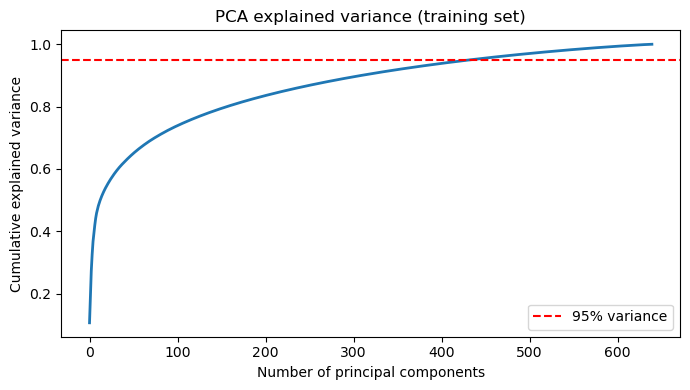

Components needed for 95% variance: 434


In [99]:
plt.figure(figsize=(7, 4))
plt.plot(explained_variance, linewidth=2)
plt.axhline(0.95, linestyle="--", color="red", label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance (training set)")
plt.legend()
plt.tight_layout()
plt.show()

# Number of components needed for 95% variance
n_95 = np.argmax(explained_variance >= 0.95) + 1
print("Components needed for 95% variance:", n_95)

**Inference:**  
A small number of principal components explain most of the variance,
indicating strong redundancy in gene expression features.
This motivates dimensionality reduction before modeling.

## Step 5 — PCA for visualization (2D)

We project the training samples onto the first two principal components.
Although 2D captures only part of the total variance, it is useful for:
- visual inspection of class separation
- identifying overlap between cancer types
- detecting outliers

In [107]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_proc)

pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "CancerType": [label_classes[i] for i in y_train]
})

## Step 6 — PCA scatter plot colored by cancer type


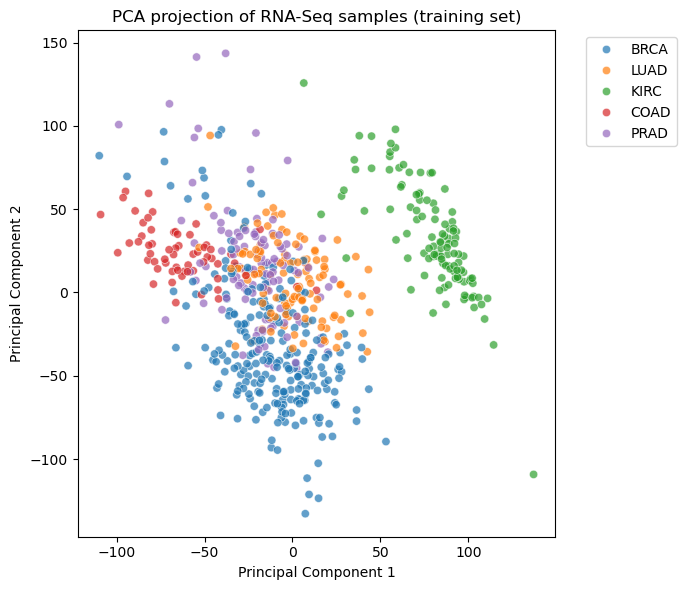

In [110]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="CancerType",
    alpha=0.7
)
plt.title("PCA projection of RNA-Seq samples (training set)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Inference:**  
Samples show partial clustering by cancer type in PCA space.
Overlap between classes suggests biological similarity and motivates supervised learning.

## Interpretation of PCA results

From the PCA visualization, we can observe:

- Partial clustering of samples by cancer type, indicating that
  gene expression profiles carry discriminative information.
- Some overlap between classes, suggesting biological similarity
  or shared molecular pathways across cancers.
- PCA captures global variance but does not optimize class separation;
  supervised models are needed for improved discrimination.

These observations motivate the use of supervised learning models
in the next stage of the analysis.

## PCA Loadings: Gene contributions to principal components

To better understand what drives the separation in PCA space,
we inspect the genes with the highest absolute loadings
on the first two principal components.

These genes contribute most strongly to the variance captured by PC1 and PC2.


In [119]:
# Load gene names retained after preprocessing
kept_genes = pd.read_csv("processed/kept_genes.csv")["gene"].tolist()

# Extract loadings
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=kept_genes
)

# Top contributing genes
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(10)

top_pc1, top_pc2


(gene_17360    0.019192
 gene_13489    0.018918
 gene_19862    0.018897
 gene_7031     0.018779
 gene_7019     0.018765
 gene_15158    0.018704
 gene_2288     0.018693
 gene_10788    0.018663
 gene_7017     0.018616
 gene_6543     0.018607
 Name: PC1, dtype: float64,
 gene_3612     0.020440
 gene_1222     0.020282
 gene_19498    0.020079
 gene_1010     0.019980
 gene_14699    0.019948
 gene_11153    0.019507
 gene_3603     0.019478
 gene_19866    0.019389
 gene_11744    0.019343
 gene_6455     0.019343
 Name: PC2, dtype: float64)

**Inference:**  
A limited subset of genes contributes most strongly to the principal components.
These genes capture dominant expression patterns and are candidates for further interpretation.

## Pairwise distances in PCA space

We compare distances between samples belonging to:
- the same cancer type
- different cancer types

This provides quantitative insight into class separation.

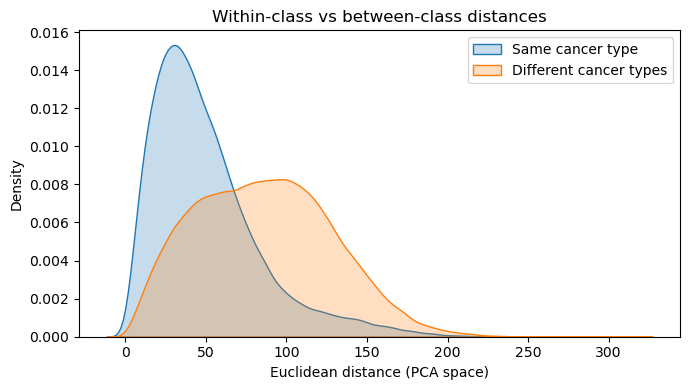

In [123]:
from sklearn.metrics import pairwise_distances

# Compute distances in PCA space
dist_matrix = pairwise_distances(X_pca_2d)

same_class = []
diff_class = []

for i in range(len(y_train)):
    for j in range(i + 1, len(y_train)):
        if y_train[i] == y_train[j]:
            same_class.append(dist_matrix[i, j])
        else:
            diff_class.append(dist_matrix[i, j])

plt.figure(figsize=(7, 4))
sns.kdeplot(same_class, label="Same cancer type", fill=True)
sns.kdeplot(diff_class, label="Different cancer types", fill=True)
plt.xlabel("Euclidean distance (PCA space)")
plt.title("Within-class vs between-class distances")
plt.legend()
plt.tight_layout()
plt.show()

**Inference:**  
Within-class distances are generally smaller than between-class distances,
indicating meaningful separation of cancer types in reduced feature space.

## EDA Summary

- Class distributions are preserved across training and test sets due to stratified sampling.
- Gene expression data is highly redundant, with a limited number of principal components
  explaining most of the variance.
- PCA projections show partial clustering by cancer type, indicating discriminative signal.
- Overlap between classes and distance analysis motivate the use of supervised learning models.